In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import statsmodels.api as sm
import matplotlib.dates as mdates
from matplotlib import ticker

from scipy import constants as const
from scipy.integrate import quad
from scipy.interpolate import interp1d

import sys
sys.path.append('..')

from models.hitran.hapi import *

pub_gray = '#cecece'
pub_purple = '#a559aa'
pub_teal = '#59a89c'
pub_gold = '#f0c571'
pub_red = '#e02b35'
pub_blue = '#082a54'

lbd_min = 1600
lbd_max = 1950

def load_regression_results(filename='regression_results.json'):
    """
    Load regression analysis results from a JSON file.
    
    Parameters
    ----------
    filename : str, optional
        Path to the JSON file containing regression results (default: 'regression_results.json')
    
    Returns
    -------
    dict
        Dictionary containing regression coefficients, standard errors, and other results
    
    Notes
    -----
    The JSON file should contain the output from regression analysis including:
    - Coefficients (const, temperature, humidity, pressure)
    - Standard errors (OLS, HAC, Prais-Winsten)
    - Bootstrap confidence intervals
    - EIV systematic errors
    """
    with open(filename, 'r', encoding='utf-8') as f:
        results = json.load(f)
    print(f"Results loaded from {filename}")
    return results


def get_h2o_spectrum(lbd_min=lbd_min, lbd_max=lbd_max):
    """
    Retrieve H₂O absorption spectrum from HITRAN database for specified wavelength range.
    
    Parameters
    ----------
    lbd_min : float, optional
        Minimum wavelength in nanometers (default: 1700 nm)
    lbd_max : float, optional
        Maximum wavelength in nanometers (default: 2150 nm)
    
    Returns
    -------
    tuple
        (wavelengths, absorption_coefficients)
        - wavelengths: Array of wavelengths in nanometers (increasing order)
        - absorption_coefficients: Array of absorption coefficients in cm²/molecule
    
    Notes
    -----
    This function accesses the HITRAN database to obtain water vapor absorption lines
    in the near-infrared region. The spectrum is retrieved for H₂O isotopologue 1.
    """
    # Initialize database connection
    db_begin('../../data/derived/models/hitran')
    
    # Convert wavelength range to wavenumber range (cm⁻¹)
    nu_min, nu_max = 1e7 / lbd_max, 1e7 / lbd_min
    
    # Fetch H₂O absorption data from HITRAN
    fetch_by_ids('H2O', [1], numin=nu_min, numax=nu_max)
    
    # Calculate absorption coefficients using Lorentzian line shape
    nu, coef = absorptionCoefficient_Lorentz(SourceTables='H2O')
    
    # Convert wavenumber to wavelength and ensure increasing order
    wavelength = 1e7 / nu
    wavelength, coef = wavelength[::-1], coef[::-1]

    return wavelength, coef


# Physical constants
k_B = const.Boltzmann  # Boltzmann constant (J/K)
f_1762 = 170.12643244933331e12
wavelength_target = 299792458 / f_1762 * 1e9  # Target wavelength in nm (1762 nm)
results_json = load_regression_results('regression_results.json')


def n_h2o_per_1pctRH(T):
    """
    Calculate water vapor number density per 1% relative humidity.
    
    Parameters
    ----------
    T : float
        Temperature in Kelvin
    
    Returns
    -------
    float
        Number density of water vapor molecules per cubic meter per 1% RH
    
    Notes
    -----
    Uses the Magnus approximation for saturation vapor pressure:
    e_s = 6.112 * exp(17.62 * T_C / (T_C + 243.12)) hPa
    where T_C = T - 273.15 (temperature in Celsius)
    """
    # Convert temperature to Celsius
    T_C = T - 273.15
    
    # Magnus approximation for saturation vapor pressure (in hPa)
    e_s_hPa = 6.112 * np.exp(17.62 * T_C / (T_C + 243.12))
    
    # Convert to Pascals
    e_s = e_s_hPa * 100.0  # Pa
    
    # Calculate number density using ideal gas law: N = P / (k_B * T)
    N_per_1pct = e_s / (k_B * T)  # molecules/m³ per 1% RH
    
    return N_per_1pct


def kk_integration(wavelength_target_nm, T=303.15, P=99000):
    """
    Perform Kramers-Kronig integration to calculate refractive index change due to water vapor.
    
    Parameters
    ----------
    wavelength_target_nm : float
        Target wavelength in nanometers
    T : float, optional
        Temperature in Kelvin (default: 303.15 K = 30°C)
    P : float, optional
        Pressure in Pascals (default: 99000 Pa)
    
    Returns
    -------
    float
        Refractive index change (Δn) per 1% relative humidity at the target wavelength
    
    Notes
    -----
    Implements the Kramers-Kronig relation:
    Δn(ν) = (1/π) * P.V. ∫ [κ(ν') / (ν' - ν)] dν'
    where κ is the absorption coefficient and P.V. denotes the Cauchy principal value.
    
    The integration handles the singularity at ν' = ν by splitting the integral
    into left and right regions with a small exclusion interval (ε).
    """
    # Retrieve H₂O absorption spectrum for the specified wavelength range
    wavelengths_nm, sigma_cm2 = get_h2o_spectrum(lbd_min, lbd_max)
    # Alternative range: wavelengths_nm, sigma_cm2 = get_h2o_spectrum(1700, 1940)
    
    # Convert absorption cross-section from cm² to m²
    sigma_m2 = np.array(sigma_cm2) * 1e-4  # cm² → m² (per molecule)
    
    # Calculate corresponding frequencies
    freqs = const.c / (wavelengths_nm * 1e-9)  # Hz
    
    # Ensure frequencies are in increasing order for interpolation
    sort_idx = np.argsort(freqs)
    freqs = freqs[sort_idx]
    sigma_m2 = sigma_m2[sort_idx]
    
    # Create interpolation function for absorption cross-section
    sigma_interp = interp1d(freqs, sigma_m2, kind='linear', 
                           bounds_error=False, fill_value=0.0)
    
    # Calculate target frequency
    nu_target = const.c / (wavelength_target_nm * 1e-9)
    nu_min = freqs.min()
    nu_max = freqs.max()
    
    # Get water vapor number density per 1% RH
    N_per_1pct = n_h2o_per_1pctRH(T)
    
    def integrand(nu_prime):
        """
        Integrand function for Kramers-Kronig relation.
        
        Parameters
        ----------
        nu_prime : float
            Integration frequency in Hz
        
        Returns
        -------
        float
            Value of κ(ν') / (ν' - ν_target)
        """
        # Get absorption cross-section at frequency nu_prime
        sigma = float(sigma_interp(nu_prime))  # m²/molecule
        
        # Skip if outside spectral range
        if sigma == 0.0:
            return 0.0
        
        # Calculate absorption coefficient: κ = N * σ * c / (4πν')
        kappa = N_per_1pct * sigma * const.c / (4.0 * np.pi * nu_prime)
        
        # Kramers-Kronig integrand
        return kappa / (nu_prime - nu_target)
    
    # Determine exclusion interval for singularity handling
    # Use spacing between frequency points as reference
    nu_spacing = np.median(np.diff(freqs))
    eps = max(nu_spacing * 5.0, 1e6)  # Minimum 1 MHz to ensure numerical stability
    
    # Perform principal value integration by splitting into left and right regions
    # Left region: from nu_min to (nu_target - ε)
    I_left, _ = quad(integrand, nu_min, max(nu_min, nu_target - eps), 
                     epsabs=1e-9, epsrel=1e-9, limit=2000)
    
    # Right region: from (nu_target + ε) to nu_max
    I_right, _ = quad(integrand, min(nu_max, nu_target + eps), nu_max, 
                      epsabs=1e-9, epsrel=1e-9, limit=2000)
    
    # Total integral (principal value)
    integral_total = I_left + I_right
    
    # Calculate refractive index change using Kramers-Kronig relation
    delta_n = (1.0 / np.pi) * integral_total  # Δn per 1% RH
    
    return delta_n


# Calculate refractive index change per 1% RH at target wavelength
delta_n_perpct = kk_integration(wavelength_target)
print(f"Δn per 1%RH = {delta_n_perpct:.4e}")

HAPI version: 1.2.2.4
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

Using ../../data/derived/models/hitran

H2O
                     Lines parsed: 11960
water
                     Lines parsed: 178

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: H2O
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  65536 bytes written to ../../data/derived/models/hitran/H2O.data
  655

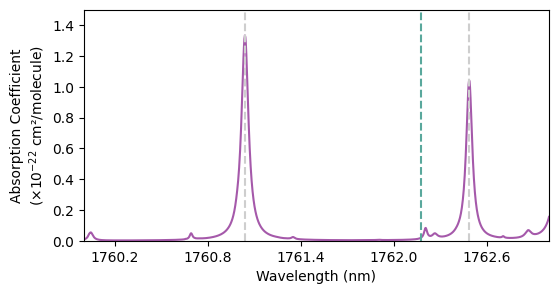

In [2]:
fig, ax = plt.subplots(figsize=(6, 3))

wavelengths_nm, alpha_abs = get_h2o_spectrum(lbd_min, lbd_max)

ax.plot(wavelengths_nm, alpha_abs*1e22, color=pub_purple, linestyle='-', label='H$_2$O Absorption (a.u.)')
ax.set_xlim(1760, 1763)
ax.set_ylim(0, 1.5)

# Highlight the 1762 nm region
ax.axvline(x=wavelength_target, color=pub_teal, linestyle='--', label='$^{138}$Ba$^+$ QN @ 1762 nm')
ax.axvline(x=1761.0402, color=pub_gray, linestyle='--')
ax.axvline(x=1762.4852, color=pub_gray, linestyle='--')

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorption Coefficient\n($\\times 10^{-22}$ cm²/molecule)')
from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.set_ylim(bottom=0)
plt.savefig('../../data/derived/figures/kramers_kronig.pdf', dpi=300, bbox_inches='tight')
plt.show()